<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_8%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**8장 차원축소**



*   많은 경우 머신러닝에서 훈련 샘플 하나가 많은 특성을 가지게 되는데, 이는 모델 학습이 느려지고 성능이 저하되는 **차원의 저주(curse of dimensionality)** 가 발생함
*   따라서 정보를 잃지 않는 선에서 데이터의 차원을 축소시키는 것이 좋음


*   특히 2,3차원으로 축소하는 경우 시각화를 통한 인사이트를 얻는데 도움이 됨





**8.1 차원의 저주**



*   단위 면적을 기준으로 2차원의 경우 넓이가 1인 사각형에서 테두리를 0.001 이라 할때, 나머지 안쪽의 넓이는 $(1-0.01\times 2) ^2 = 0.996$ 임
*   3차원의 경우 안쪽의 넓이는 $(1 - 0.002)^3 \approx 0.994$ 이고, 1만 차원의 경우 안쪽의 넓이는 $(1 - 0.002)^{10,000} \approx \mathbf{0.000000002}$ 로 계속 감소하는 모습을 보여줌(나머지는 전부 테두리의 크기)



*   즉, 차원이 증가할수록 샘플간의 거리가 아주아주 멀어지는 상황이 생김(끝부분 테두리로 갈 확률이 올라가므로)



*   차원별 0과 1사이의 피타고라스를 이용한 거리 비교는 다음과 같음
*   2차원 대각선: $\sqrt{1^2 + 1^2} = \sqrt{2} \approx 1.41$
*   3차원 대각선: $\sqrt{1^2 + 1^2 + 1^2} = \sqrt{3} \approx 1.73$
*   1,000,000차원 대각선: $\sqrt{1^2 + 1^2 + \dots + 1^2} = \sqrt{1,000,000} = \mathbf{1,000}$ 으로 거리가 엄청 멀어짐


*   따라서 차원이 크다면 새로운 샘플도 훈련 샘플과 멀리 떨어져 있을 확률이 증가함


*   이에 따라 모델이 본 적 없는 데이터에 대한 예측을 진행해야 하는 **외삽(extrapolation)** 의 양이 많아져 예측이 불안정해짐 (과대적합 위험이 커짐(샘플에 맞추려고 하다보니))
*   이론적으로는 이를 해결하기 위해 훈련 샘플들의 밀도가 충분히 높아질 때까지 샘플 수를 늘리면 되지만 차원 수가 늘어날수록 이를 만족하기 위해 필요한 샘플의 수가 기하급수적으로 늘어나 현실적으로는 불가능함

**8.2 차원 축소를 위한 접근법**


*   차원 축소를 위한 주요한 방법에는 투영과 매니폴드 학습이 있음



**8.2.1 투영**



*   여러 특성들 중 한 차원이 크기 않은 범위에서 퍼져있는 경우, 모든 샘플과의 거리가 최소가 되는 평면을 하나 구할 수 있음
*   이 구해진 평면으로 데이터를 수직 이동시켜 평면 위에 위치하도록 하, 정보량의 손실을 최소화하면서 차원을 줄일 수 있음
*   그러나 **스위스 롤** 데이터셋과 같이 데이터가 고차원에서 말려있는 경우,투영은 좋은 차원축소 방식이 아님(평면으로 투영시키기 떄문에 비선형적 특성이 뭉개져서 사라지는 문제가 발생)


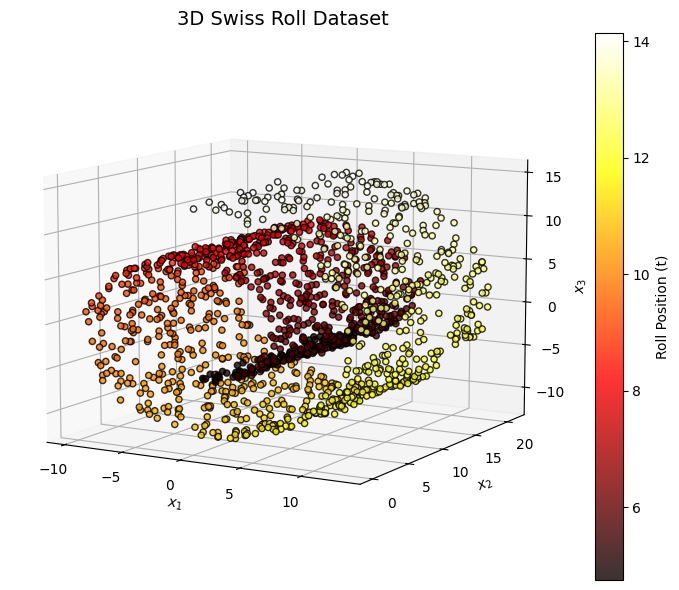

In [ ]:
#스위스 롤 데이터셋 시각화

import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# 1. 스위스 롤 데이터셋 생성
X, t = make_swiss_roll(n_samples=1500, noise=0.2, random_state=42)

# 2. 3D 시각화
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=t,
    cmap=plt.cm.hot,
    edgecolor="k",
    s=20,
    alpha=0.8
)

ax.set_title("3D Swiss Roll Dataset", fontsize=14)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")

# 책(그림 8-4) 시점과 유사하게 카메라 각도 설정
ax.view_init(elev=10, azim=-60)

fig.colorbar(scatter, ax=ax, label="Roll Position (t)")
plt.tight_layout()
plt.show()

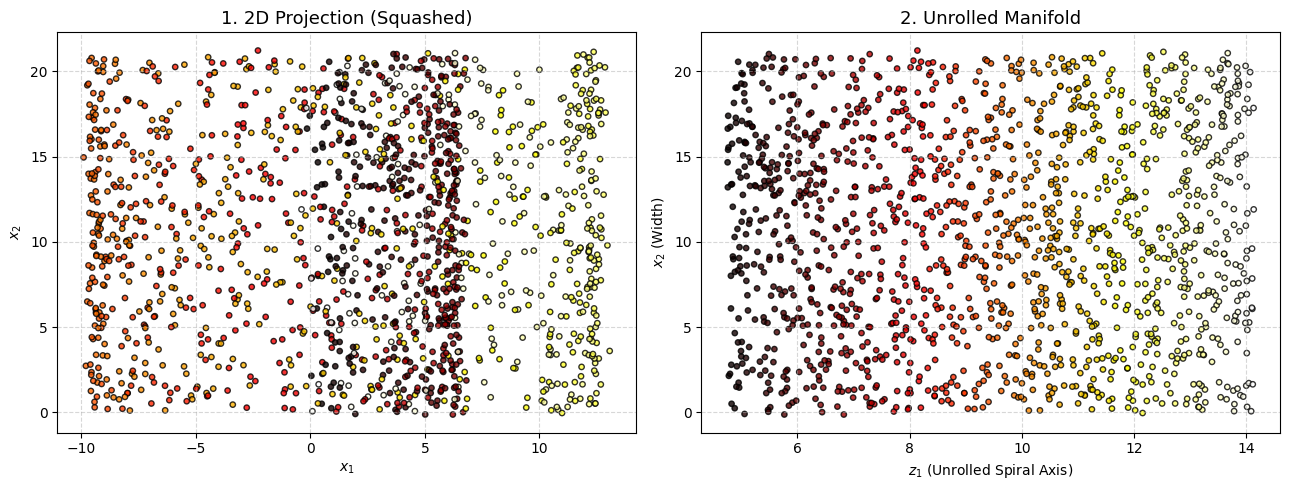

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# 1. 데이터 생성
X, t = make_swiss_roll(n_samples=1500, noise=0.2, random_state=42)

# 2. 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# [왼쪽] 단순 평면 투영 (x3 버림)
axes[0].scatter(
    X[:, 0], X[:, 1],
    c=t, cmap=plt.cm.hot, edgecolor="k", s=15, alpha=0.8
)
axes[0].set_title("1. 2D Projection (Squashed)", fontsize=13)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].grid(True, linestyle="--", alpha=0.5)

# [오른쪽] 매니폴드 언롤링
axes[1].scatter(
    t, X[:, 1],
    c=t, cmap=plt.cm.hot, edgecolor="k", s=15, alpha=0.8
)
axes[1].set_title("2. Unrolled Manifold", fontsize=13)
axes[1].set_xlabel("$z_1$ (Unrolled Spiral Axis)")
axes[1].set_ylabel("$x_2$ (Width)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**8.2.2 매니폴드 학습**



*   **$d$차원 매니폴드**는 국부적으로 $d$차원으로 보이지만, $n$($d<n$)차원 공간의 일부임(스위스 롤 데이터셋의 경우 $d=2$, $n=3$ 인 경우에 해당함)
*   많은 차원축소 알고리즘이 훈련 샘플이 놓여있는 **매니폴드(manifold)** 를 모델링 하는 식으로 작동하고, 이를 **매니폴드 학습** 이라고 함


*   대부분의 실제 고차원의 데이터셋이 더 낮은 저차원 매니폴드에 가깝게 놓여있는 **매니폴드 가설** 에 근거함
*   **즉, 고차원의 데이터셋이라도, 그 데이터셋은 일부 몇몇 주요 특성에게 큰 영향을 받아(저차원) 충분히 압축 가능하다고 가정함**
*   따라서 **저차원으로 펼쳐두면 더 잘 축소할 수 있다고 가정**하는 것임
*   앞부분에서 사용한 MNIST 데이터셋 같은 경우도 대부분의 픽셀이 흰색이고,  선의 연결, 기울기, 두께 같은 몇 안 되는 규칙(자유도)들이 숫자를 판가름하는데 이용됨  

*   그러나 항상 성립하는 것은 아니고 데이터셋에 따라 좋은 솔루션이 아닐 수 있음(그래도 차원축소하면 훈련 시간은 단축됨)









**8.3 주성분 분석**


*   **주성분 분석(principal component analysis, PCA)** 은 가장 인기있는 차원 축소 알고리즘으로, **데이터에 가장 가까운 초평면을 정의한 다음, 데이터를 이 평면에 투영시키는 방식임**



**8.3.1 분산 보존**


*   가장 좋은 초평면 = 데이터의 분산이 최대로 보존되는 평면(축) 이며, 이는 곧 원본 데이터셋과 투영된 데이터 사이의 평균 제곱 거리가 최소화 되는 평면(축)을 말함



**8.3.2 주성분**


*   PCA는 훈련 세트에서 분산이 최대가 되는 축을 찾고, 그 축과 직교하면서 그다음으로 분산을 잘 설명하는 축을 찾는 과정을 반복(앞서 구한 축들과 직교하면서 차원 수만큼 찾게 됨)
*   이때, $i$번째 축을 이 데이터의 $i$번째 **주성분(principal component,PC)** 라고 함



*   각 주성분을 위해 PCA는 주성분 방향을 가리키고 원점에 중앙이 맞춰진 단위 벡터를 찾음. 간혹 데이터를 섞은 후 다시 PCA를 진행하면 벡터의 반대일수는 있지만 일반적으로 같은 축에 놓여 있을 것임. 혹은 두 축의 분산이 매우 비슷하다면 한쌍의 축들이 회전하거나 바뀔수 있지만 보통 같은 평면을 구성할 것임(데이터가 섞여도 축이 가리키는 방향만 달라질 뿐 주성분 축은 큰 변화가 없다는 말)


**주성분 찾는 법**


*   주성분은 **특잇값 분해(singular value decomposition, SVD)** 을 통해 구하게 됨

*   SVD는 데이터 행렬을 아래와 같이 분해함(이때 데이터 행렬은 평균이 0인 중심화가 되어있어야 함)
$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$$



*   이때, $\mathbf{V}^T$를  다시 전치시킨 $\mathbf{V}$ 의 **컬럼 벡터들**이 모두 주성분의 단위벡터가 됨






In [ ]:
#넘파이의 svc()를 사용하기

import numpy as np
# X = [데이터셋]
# X_centered = X-X.mean(axis=0)
# U,s,Vt = np.linalg.svd(X_centered)
#c1 = Vt[0] # 첫 번째 주성분
#c2 = Vt[1] # 두 번째 주성분



*   **PCA는 데이터셋의 평균이 0이라 가정함. 따라서 전처리 과정에서 각 특성별로  평균을 빼서 평균을 0으로 맞춰주는 작업을 해줘야 함**(PCA 라이브러리는 이 작업을 알아서 진행함)


**8.3.3 $d$ 차원으로 투영하기**



*   주성분을 모두 추출했다면 처음 $d$개의 주성분으로 정의한 초평면에 투영하여 데이터를 $d$차원으로 축소시킬 수 있음
*  투영시키는 방법은 다음과 같음

    $\mathbf{X}_{d-proj} = \mathbf{X}\mathbf{W}_d$



*   이때, $\mathbf{W}_d$는 주성분벡터 $V$의 열벡터를 순서대로 $d$개 놓은 행렬임



In [ ]:
#코드

# W2 = Vt[:2].T  #d=2로 설정
# X2D = X_centered @ W2 # 연산

**8.3.4 사이킷런 이용하기**



*   사이킷런의 PCA는 앞서 구현한 SVD 기반임



In [ ]:
#PCA를 통해 데이터의 차원을 2차원으로 줄이는 코드(자동으로 데이터들의 평균을 0으로 맞춰줌)

from sklearn.decomposition import PCA

#pca = PCA(n_components=2) # n_components 하이퍼파라미터로 차원 수 지정
#X2D = pca.fit_transform(X) #fit_transform을 해줘야 계산까지 한번에 완료



*   **.compontents_** 속성에 $\mathbf{W}_d$의 전치가 담겨있고, 이때 이 배열의 행들은 처음 $d$개의 주성분임




**8.3.5 설명된 분산의 비율**



*   **.explained_variance_ratio_** 를 통해 변수에 저장된 주성분의 **설명된 분산의 비율(explained variance ratio)**를 구할 수 있음
*   이 비율은 각 주성분의 축을 따라 있는 데이터셋의 분산 비율을 나타냄($\frac{해당 축의 분산}{전체 분산}$)

In [ ]:
#PCA를 한 변수명.explained_variance_ratio_ 로 확인 가능
#pca.explained_variance_ratio_